# Sandpile on Free Associations Network

Experiment: compare **Random** vs **Targeted** grain addition on a Free Association network using the Abelian Sandpile with stochastic dissipation (f=10⁻⁴).

**Measures:**
1. Avalanche Frequency — fraction of iterations producing at least one toppling
2. Avalanche Size — total grains moved per avalanche (Σ deg of toppled nodes)
3. Unique Toppled Nodes — number of distinct nodes involved per avalanche
4. Total Topplings — toppling events per avalanche (with repetitions)
5. Target Involvement — how often the target node is involved in avalanches

In [60]:
import sys
sys.path.insert(0, '..')

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

from SpreadPy.Models.sandpile import SandpileSpreading

np.random.seed(42)

## 1. Load Free Associations Network

In [61]:
# Build graph from edge list
g = nx.Graph()
with open('../toy_data/mental_lexicon_2/FreeAssociations.txt') as f:
    for line in f:
        parts = line.strip().split('	')
        if len(parts) == 2:
            g.add_edge(parts[0], parts[1])

# Remove self-loops
g.remove_edges_from(nx.selfloop_edges(g))

# Remove degree-0 nodes
isolates = list(nx.isolates(g))
g.remove_nodes_from(isolates)
print(f"Removed {len(isolates)} isolated nodes")

# Take largest connected component
largest_cc = max(nx.connected_components(g), key=len)
g = g.subgraph(largest_cc).copy()

print(f"Nodes: {g.number_of_nodes()}")
print(f"Edges: {g.number_of_edges()}")
print(f"Avg degree: {2 * g.number_of_edges() / g.number_of_nodes():.1f}")

Removed 0 isolated nodes
Nodes: 11512
Edges: 36375
Avg degree: 6.3


## 2. Load Dataset & Sample 100 Pairs

In [ ]:
df = pd.read_excel('../data/all naming subjects.xlsx')

# Keep only related pairs (primecond=1), lowercase, deduplicate
related = df[df['primecond'] == 1.0][['prime', 'target']].drop_duplicates()
related['prime'] = related['prime'].str.lower()
related['target'] = related['target'].str.lower()

# Keep only pairs where both words exist in the network
nodes = set(g.nodes())
related = related[(related['prime'].isin(nodes)) & (related['target'].isin(nodes))]
print(f"Related pairs with both words in network: {len(related)}")

# Sample N pairs
pairs = related.sample(n=100, random_state=42).reset_index(drop=True)
print(f"Sampled {len(pairs)} pairs")
pairs.head(10)

Related pairs with both words in network: 1640
Sampled 2 pairs


,prime,target
0,world,earth
1,pancakes,syrup


## 3. Run Experiments

For each pair, run two sandpile simulations with N iterations:
- **Random**: add grain to a random node each step
- **Targeted**: always add grain to the cue (prime) node

In [ ]:
N_ITERATIONS = 150000  # iterations per simulation
F = 1e-4             # dissipation probability

def run_sandpile(graph, n_iter, target_node=None, cue_node=None):
    """
    Run a sandpile simulation and collect avalanche metrics.
    
    :param graph: networkx graph
    :param n_iter: number of iterations
    :param target_node: if set, track whether this node is involved in avalanches
    :param cue_node: if set, always add grain to this node (targeted mode)
    :return: dict with collected metrics
    """
    model = SandpileSpreading(graph, f=F)
    
    avalanche_sizes = []
    avalanche_topplings = []
    unique_toppled = []
    target_involved = []  # True/False per iteration
    
    # iteration 0 (initial config)
    model.iteration()
    
    for _ in range(n_iter):
        result = model.iteration(node=cue_node)
        
        avalanche_sizes.append(result['avalanche_size'])
        avalanche_topplings.append(result['total_topplings'])
        unique_toppled.append(result['unique_toppled_nodes'])
        
        if target_node is not None:
            target_involved.append(target_node in result['toppled_nodes'])
    
    return {
        'avalanche_sizes': avalanche_sizes,
        'avalanche_topplings': avalanche_topplings,
        'unique_toppled': unique_toppled,
        'target_involved': target_involved,
    }

In [68]:
results_random = []
results_targeted = []

for idx, row in tqdm(pairs.iterrows(), total=len(pairs), desc="Running experiments"):
    cue = row['prime']
    target = row['target']
    
    # Case 1: Random addition
    res_r = run_sandpile(g, N_ITERATIONS, target_node=target, cue_node=None)
    results_random.append(res_r)
    
    # Case 2: Targeted addition (always add to cue)
    res_t = run_sandpile(g, N_ITERATIONS, target_node=target, cue_node=cue)
    results_targeted.append(res_t)

Running experiments: 100%|██████████| 2/2 [19:27<00:00, 583.59s/it]


### Checkpoint: Salvataggio e Caricamento dei dati
Queste celle permettono di salvare i risultati delle simulazioni su disco e ricaricarli in un secondo momento, utile per modificare l'analisi senza dover rifare i lunghi calcoli.

In [ ]:
import pickle
import os

# Assicurati che la cartella esista
os.makedirs('../data', exist_ok=True)

# Salva i risultati
with open('../data/sandpile_results.pkl', 'wb') as f:
    pickle.dump({'random': results_random, 'targeted': results_targeted}, f)
print("Risultati salvati in ../data/sandpile_results.pkl")

In [ ]:
import pickle

# Decommenta le righe seguenti per ricaricare i dati senza rifare le simulazioni in alto
# with open('../data/sandpile_results.pkl', 'rb') as f:
#     data = pickle.load(f)
#     results_random = data['random']
#     results_targeted = data['targeted']
# print(f"Risultati caricati con successo: {len(results_random)} simulazioni random, {len(results_targeted)} targeted.")

## 4. Analysis

### Avalanche Size Distribution

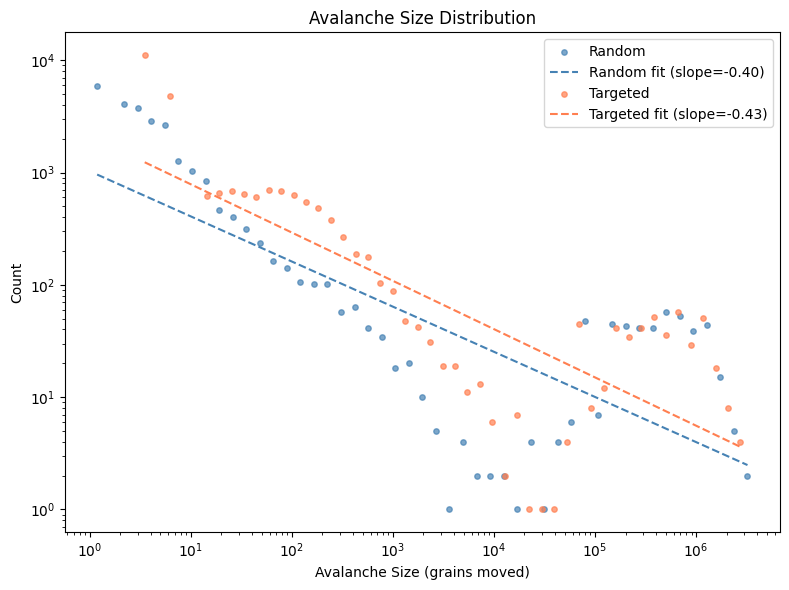

In [70]:
# Collect all non-zero avalanche sizes
sizes_random = [s for r in results_random for s in r['avalanche_sizes'] if s > 0]
sizes_targeted = [s for r in results_targeted for s in r['avalanche_sizes'] if s > 0]

def loglog_hist(ax, data, color, label):
    """Plot log-binned histogram as scatter + power-law fit."""
    bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 50)
    counts, edges = np.histogram(data, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    mask = counts > 0
    ax.scatter(centers[mask], counts[mask], s=15, color=color, alpha=0.7, label=label)
    # power-law fit in log-log
    log_x = np.log10(centers[mask])
    log_y = np.log10(counts[mask])
    slope, intercept = np.polyfit(log_x, log_y, 1)
    fit_x = np.logspace(log_x.min(), log_x.max(), 100)
    ax.plot(fit_x, 10**intercept * fit_x**slope, '--', color=color, linewidth=1.5,
            label=f'{label} fit (slope={slope:.2f})')

fig, ax = plt.subplots(figsize=(8, 6))
loglog_hist(ax, sizes_random, 'steelblue', 'Random')
loglog_hist(ax, sizes_targeted, 'coral', 'Targeted')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Avalanche Size (grains moved)')
ax.set_ylabel('Count')
ax.set_title('Avalanche Size Distribution')
ax.legend()
plt.tight_layout()
plt.show()

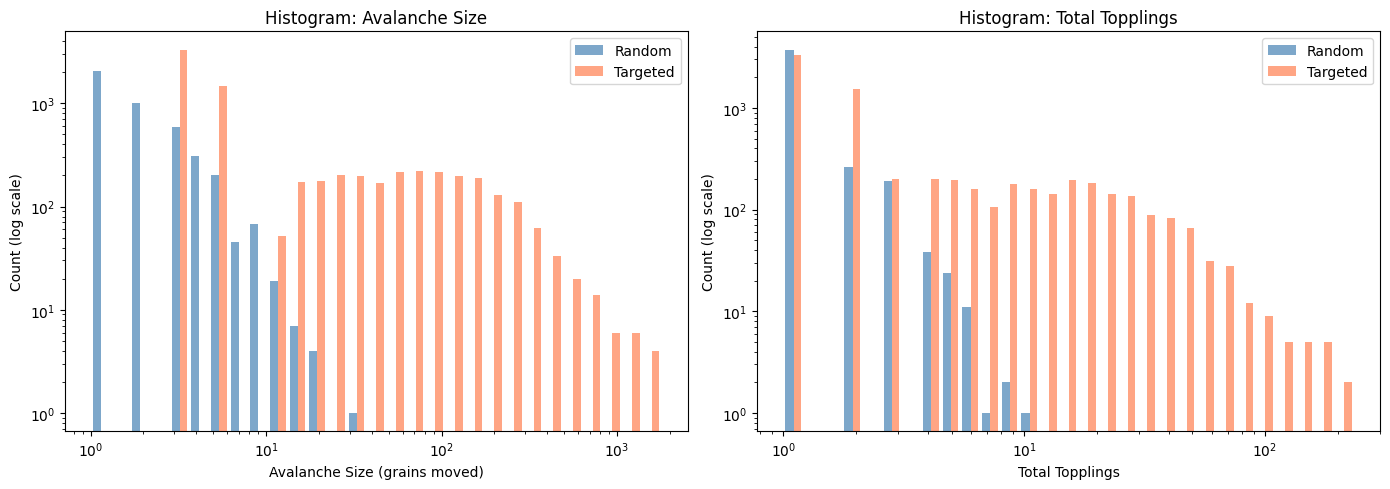

In [69]:
# Crea una figura con due grafici affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Istogramma per le Avalanche Sizes (Grani spostati)
max_size = max(max(sizes_random, default=1), max(sizes_targeted, default=1))
# Creiamo dei "contenitori" (bins) in scala logaritmica per raggruppare bene i dati
bins_size = np.logspace(0, np.log10(max_size), 30) if max_size > 1 else 30

ax1.hist([sizes_random, sizes_targeted], bins=bins_size, color=['steelblue', 'coral'], 
         label=['Random', 'Targeted'], alpha=0.7, log=True) # log=True mette l'asse Y in scala log
ax1.set_xscale('log') # Anche l'asse X in scala logaritmica
ax1.set_xlabel('Avalanche Size (grains moved)')
ax1.set_ylabel('Count (log scale)')
ax1.set_title('Histogram: Avalanche Size')
ax1.legend()

# 2. Istogramma per i Total Topplings
max_top = max(max(topplings_random, default=1), max(topplings_targeted, default=1))
bins_top = np.logspace(0, np.log10(max_top), 30) if max_top > 1 else 30

ax2.hist([topplings_random, topplings_targeted], bins=bins_top, color=['steelblue', 'coral'], 
         label=['Random', 'Targeted'], alpha=0.7, log=True)
ax2.set_xscale('log')
ax2.set_xlabel('Total Topplings')
ax2.set_ylabel('Count (log scale)')
ax2.set_title('Histogram: Total Topplings')
ax2.legend()

plt.tight_layout()
plt.show()


### Total Topplings per Grain Addition

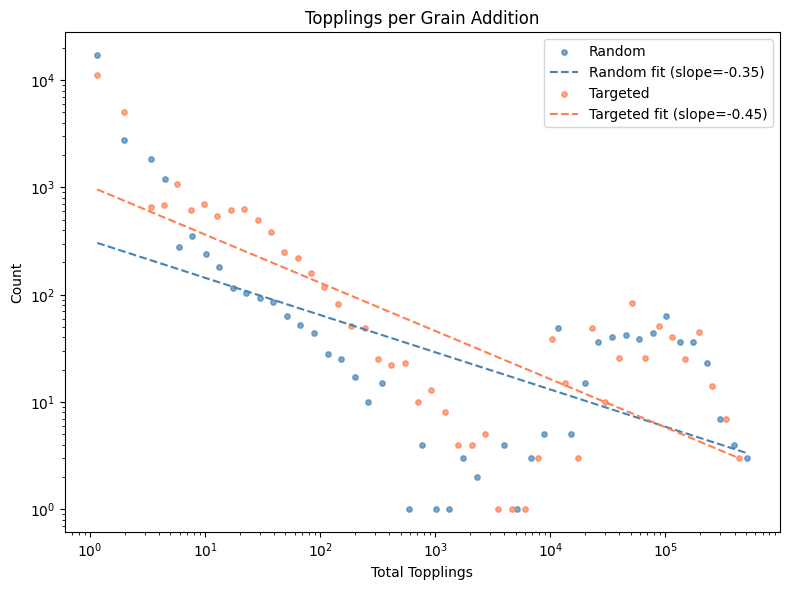

In [71]:
topplings_random = [t for r in results_random for t in r['avalanche_topplings'] if t > 0]
topplings_targeted = [t for r in results_targeted for t in r['avalanche_topplings'] if t > 0]

fig, ax = plt.subplots(figsize=(8, 6))
loglog_hist(ax, topplings_random, 'steelblue', 'Random')
loglog_hist(ax, topplings_targeted, 'coral', 'Targeted')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Total Topplings')
ax.set_ylabel('Count')
ax.set_title('Topplings per Grain Addition')
ax.legend()
plt.tight_layout()
plt.show()